## Phase 1: Data Understanding and Initial Exploration

Standard Python Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt


In [2]:
hospital_df = pd.read_csv('../data/raw/hospital data analysis.csv')
hospital_df.head()

,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
0,1,45,Female,Heart Disease,Angioplasty,15000,5,No,Recovered,4
1,2,60,Male,Diabetes,Insulin Therapy,2000,3,Yes,Stable,3
2,3,32,Female,Fractured Arm,X-Ray and Splint,500,1,No,Recovered,5
3,4,75,Male,Stroke,CT Scan and Medication,10000,7,Yes,Stable,2
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000,10,No,Recovered,4


In [11]:
hospital_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   patient_id      984 non-null    int64   
 1   age             984 non-null    int64   
 2   gender          984 non-null    object  
 3   condition       984 non-null    object  
 4   procedure       984 non-null    object  
 5   cost            984 non-null    int64   
 6   length_of_stay  984 non-null    int64   
 7   readmission     984 non-null    object  
 8   outcome         984 non-null    object  
 9   satisfaction    984 non-null    int64   
 10  age_group       984 non-null    category
 11  cost_bucket     918 non-null    category
dtypes: category(2), int64(5), object(5)
memory usage: 79.3+ KB


>Since the data is simulated data from Kaggle, it has no excessive missing data.

In [4]:
hospital_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Patient_ID,984.0,500.329268,288.979531,1.0,250.75,500.5,750.25,1000.0
Age,984.0,53.754065,14.941135,25.0,45.00,55.0,65.00,78.0
Cost,984.0,8367.479675,7761.990976,100.0,1000.00,6000.0,15000.00,25000.0
Length_of_Stay,984.0,37.663618,19.595805,1.0,21.00,38.0,54.25,76.0
Satisfaction,984.0,3.598577,0.883002,2.0,3.00,4.0,4.00,5.0


> Initial inspection reveals a wide age range (25–78), with an average cost of $8,367 and  
> average length of stay of 38 days. Satisfaction scores skew high (avg 3.6), and no missing
> data is present.  
> This suggests the dataset is clean and ready for exploratory analysis.


### Column Normalization
In order to proceed and mitigate time wasting syntax errors, it is best to take all the headers  
and set them to lowercase.  This will normalize the data and make it better to read and code with.

In [5]:
hospital_df.columns = hospital_df.columns.str.lower()
hospital_df.columns

Index(['patient_id', 'age', 'gender', 'condition', 'procedure', 'cost',
       'length_of_stay', 'readmission', 'outcome', 'satisfaction'],
      dtype='object')

#### Creating Age Bands and Cost Buckets
To better understand patterns within the dataset, age and cost values are grouped into meaningful categories.  
Segmenting patients into age bands helps reveal how different life stages relate to hospital utilization,  
while cost buckets make it easier to identify which groups are associated with higher or lower treatment expenses.  
These engineered features support clearer visualizations, more interpretable insights, and stronger modeling performance.

In [6]:
# Creating Age Groups
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
hospital_df['age_group'] = pd.cut(hospital_df['age'], bins=age_bins, labels=age_labels, right=False)

# Creating the Cost Buckets
cost_bins = [0, 2000, 10000, 25000]
cost_labels = ['Low', 'Medium', 'High']
hospital_df['cost_bucket'] = pd.cut(hospital_df['cost'], bins=cost_bins, labels=cost_labels, right=False)

### Distribution Review

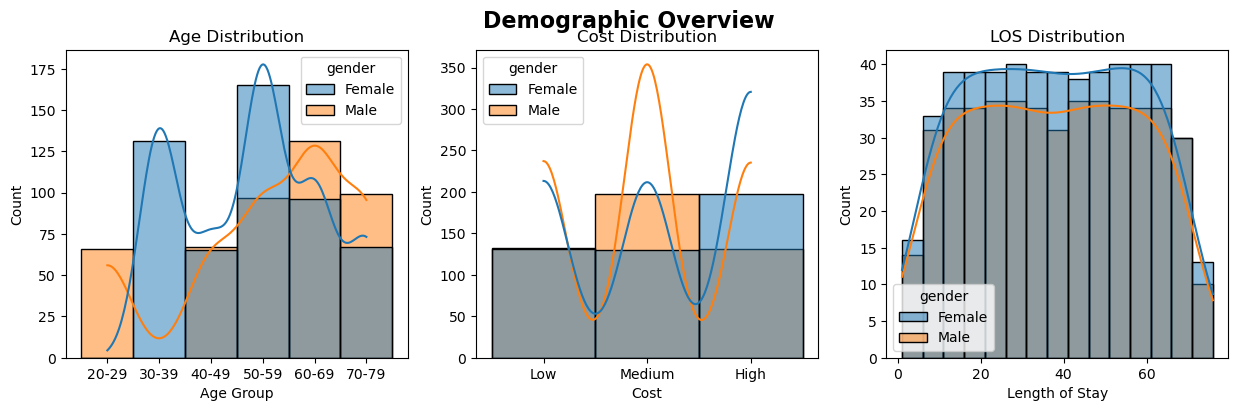

In [7]:
# Setup the figure layout
fig, axes = plt.subplots(1,3, figsize=(15, 4))
fig.suptitle('Demographic Overview', fontsize=16, fontweight ='bold')

# Age Distribution
sns.histplot(data=hospital_df, x='age_group', bins=age_bins, hue='gender', ax=axes[0],kde=True, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')

# Cost Distribution
sns.histplot(data=hospital_df, x='cost_bucket', bins=cost_bins, ax=axes[1], hue='gender', kde=True, color='steelblue', edgecolor='black')
axes[1].set_title('Cost Distribution')
axes[1].set_xlabel('Cost')
axes[1].set_ylabel('Count')

# Length of Stay Distribution
sns.histplot(data=hospital_df, x='length_of_stay', bins=15, ax=axes[2], hue='gender', kde=True, color='steelblue', edgecolor='black')
axes[2].set_title('LOS Distribution')
axes[2].set_xlabel('Length of Stay')
axes[2].set_ylabel('Count')

plt.show()

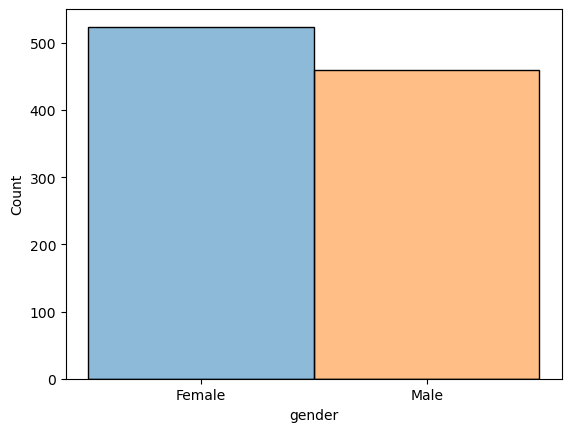

In [8]:
sns.histplot(data= hospital_df, x='gender', hue='gender', legend=False);

**Distribution Summary**  

The ratio between males and females is negligible; they are very close to even distribution with a slightly higher female population.  
However, the Age Groups between males and females indicate that the male population is concentrated between 40 to 70 years of age, while  
females have two distinct concentrations of patients, the first concentration between 30 to 40, and the second distribution with a higher 
count in the range between 50 to 60.  

Finally, the length of stay between both genders is about the same, but with a slightly higher count of females in comparison to their  
male counterparts.  The plot illustrates that, on average, patients' shortest time to stay is approximately 15 days, and maximum typical stays  
for longer stays are about 60 days, with the mean approximately 40, which coincides with what we saw in the data description.

In [9]:
# Phase 1 output
hospital_df.to_csv('../data/processed/phase1_cleaned.csv', index=False)